# Week 4: Predict & Explain — Regression on Real DASS Data

Welcome to your first machine learning modelling challenge! You'll build regression models to predict depression scores from personality traits and demographics, using real data from nearly 40,000 people.

**In this lab, you'll use the vocabulary from Week 3** — features, targets, train/test splits, cross-validation, regularisation — on a real dataset.

**Remember the LLM Problem-Solving Loop:**

**Outer loop (your research process):** PLAN → EXECUTE → EVALUATE → DOCUMENT

**Inner loop (working with the AI):** ENGINEER → PLAN → GENERATE → VERIFY → REFINE

**This week's new skill: debugging.** When code breaks, share the full error with your AI assistant and ask it to explain what went wrong — not just fix it.

See the [challenge brief (README.md)](README.md) for full details.

---

In [9]:
# === IMPORTS ===
# These are the libraries you'll use today.
# pandas: for loading and working with data tables
# numpy: for numerical operations
# matplotlib + seaborn: for creating plots
# sklearn: for building and evaluating regression models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

# Set some defaults so our plots look nice
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [10]:
# === LOAD THE DATA ===
# This file is TAB-separated (not comma-separated), so we need sep="\t"
# If you forget this, you'll get a DataFrame with 1 column — a common gotcha!

data = pd.read_csv("data/dass42_data.csv", sep="\t")

# Always check shape and head right after loading
print(f"Dataset shape: {data.shape[0]} respondents, {data.shape[1]} variables")
print()
data.head()

Dataset shape: 39775 respondents, 172 variables



,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,...,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,...,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,...,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,...,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,...,2,2,3,10,1,10,2,1,4,Psychology


## Step 1: Quick Data Review

Before doing anything else, let's understand what we're working with. This dataset has 172 columns — that's a lot! The key variable groups are:

- **Q1A – Q42A**: DASS-42 item responses (coded 1–4)
- **TIPI1 – TIPI10**: Big Five personality items (coded 1–7)
- **Demographics**: age, gender, education, urban, married, familysize, etc.
- **VCL1 – VCL16**: Vocabulary check (VCL6, VCL9, VCL12 are fake words)
- **Q1E – Q42E**: Item response times (milliseconds) — careful, these are a trap!

Run the cell below to get summary statistics and check for missing values.

In [11]:
# Summary statistics for key columns
key_cols = ["age", "gender", "education", "TIPI1", "TIPI2", "TIPI3", "TIPI4", "TIPI5",
            "Q3A", "Q5A", "Q10A"]  # a few DASS items
print("Summary statistics for key variables:")
print(data[key_cols].describe().round(2))
print()

# Check for missing values in DASS items and TIPI items
dass_cols = [f"Q{i}A" for i in range(1, 43)]
tipi_cols = [f"TIPI{i}" for i in range(1, 11)]
print(f"Missing values in DASS items: {data[dass_cols].isnull().sum().sum()}")
print(f"Missing values in TIPI items: {data[tipi_cols].isnull().sum().sum()}")
print()

# Check the age distribution — are there any clearly wrong values?
print(f"Age range: {data['age'].min()} to {data['age'].max()}")
print(f"Ages > 100: {(data['age'] > 100).sum()}")

Summary statistics for key variables:
            age    gender  education     TIPI1     TIPI2     TIPI3     TIPI4  \
count  39775.00  39775.00   39775.00  39775.00  39775.00  39775.00  39775.00   
mean      23.61      1.79       2.50      3.79      4.19      4.74      5.17   
std       21.58      0.44       0.89      1.90      1.82      1.80      1.83   
min       13.00      0.00       0.00      0.00      0.00      0.00      0.00   
25%       18.00      2.00       2.00      2.00      3.00      4.00      4.00   
50%       21.00      2.00       3.00      4.00      5.00      5.00      6.00   
75%       25.00      2.00       3.00      5.00      6.00      6.00      7.00   
max     1998.00      3.00       4.00      7.00      7.00      7.00      7.00   

          TIPI5       Q3A       Q5A      Q10A  
count  39775.00  39775.00  39775.00  39775.00  
mean       4.93      2.23      2.52      2.45  
std        1.72      1.04      1.07      1.14  
min        0.00      1.00      1.00      1.00  
2

## Step 2: Basic Cleaning

The data has some quality issues we should fix before modelling:

1. **Bad ages** — some respondents entered their birth year (e.g., 1998) instead of their age. We'll keep only ages 10–100.
2. **Careless responders** — the vocabulary check includes three fake words (VCL6, VCL9, VCL12). Anyone who claims to know 2 or more fake words was probably not paying attention.

Run the cell below to clean the data.

In [12]:
# Filter unreasonable ages
print(f"Before cleaning: {len(data)} rows")

data = data[(data["age"] >= 10) & (data["age"] <= 100)]
print(f"After age filter (10-100): {len(data)} rows")

# Remove careless responders (endorsed 2+ fake vocabulary words)
fake_words = ["VCL6", "VCL9", "VCL12"]
data["vcl_fake_count"] = data[fake_words].sum(axis=1)
n_careless = (data["vcl_fake_count"] >= 2).sum()
data = data[data["vcl_fake_count"] < 2]
print(f"Removed {n_careless} careless responders")
print(f"Clean dataset: {len(data)} rows")

Before cleaning: 39775 rows
After age filter (10-100): 39768 rows
Removed 1148 careless responders
Clean dataset: 38620 rows


/var/folders/zn/zt98lnx551s583zwr_1vmdzm0000gn/T/ipykernel_58989/262793063.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["vcl_fake_count"] = data[fake_words].sum(axis=1)


## Step 3: PLAN Your Analysis

Before writing any modelling code, ask your AI assistant to create an analysis plan. This is the **PLAN** step of the outer loop — and it's the most important one.

**Why plan first?** A written plan catches misunderstandings before code is written. It's much easier to say "actually, let's try different features" when you're looking at a plan than after the AI has written 100 lines of modelling code.

### What to do

1. Open your AI assistant (Copilot Chat, ChatGPT, Claude, etc.)
2. Use this prompt (or adapt it):

> "I have a pandas DataFrame called `data` loaded from a tab-separated file with 39,775 rows and 172 columns. This is real survey data from the Depression Anxiety Stress Scales (DASS-42). The key variables are: 42 DASS items (Q1A–Q42A, coded 1–4), which need recoding to 0–3 and summing into Depression, Anxiety, and Stress subscales. The target is DASS Depression (14 items, total 0–42). Potential features include: Big Five personality (TIPI1–TIPI10), demographics (age, gender, education, urban, married, familysize, orientation, race), and vocabulary check items (VCL1–VCL16, where VCL6, VCL9, VCL12 are fake words for validity screening). Create a plan for building and comparing regression models (linear regression, Ridge, and Lasso) to predict depression scores from personality and demographics. Include: how to score the DASS subscales, which features to use and why, how to handle data quality, how to split the data, how to evaluate the models, and how to compare them. Don't write code yet — just the plan."

3. **Paste the AI's plan in the cell below.** Review it, revise if needed.

### Your AI-Generated Plan

*Paste your AI's analysis plan here. Double-click this cell to edit it.*

**Plan for Building and Comparing Regression Models to Predict DASS Depression Scores**

This plan outlines a structured approach to preprocess the DASS-42 survey data, build regression models (linear regression, Ridge, and Lasso) to predict Depression subscale scores from personality and demographic features, and evaluate/compare the models. The focus is on predicting the Depression subscale (sum of 14 items, range 0–42) using Big Five personality traits (TIPI1–TIPI10) and demographics (age, gender, education, urban, married, familysize, orientation, race). Vocabulary check items (VCL1–VCL16) will be used for data quality screening but not as predictive features, as they are primarily for validity assessment rather than direct prediction of depression.

**1. Data Preparation and Quality Handling**  
 - **Recode DASS Items and Compute Subscales:**  
   + The 42 DASS items (Q1A–Q42A) are coded 1–4 (corresponding to the following response options: 1=*Did not apply to me all*, 2=*Applied to me to some degree or some of the time*, 3=*Applied to me to a considerable degree or a good part of time*, 4=*Applied to me very much or most of the time*).  
   + Recode to 0–3 by subtracting 1 from each item (e.g., 1→0, 2→1, 3→2, 4→3).  
   + Compute subscale scores by summing the recoded items for each subscale:  
     - **Depression** (target variable): Sum of Q3A, Q5A, Q10A, Q13A, Q16A, Q17A, Q21A, Q24A, Q26A, Q31A, Q34A, Q37A, Q38A, Q42A (14 items, range 0–42).  
     - **Anxiety**: Sum of Q2A, Q4A, Q7A, Q9A, Q15A, Q19A, Q20A, Q23A, Q25A, Q28A, Q30A, Q36A, Q40A, Q41A (14 items, range 0–42).  
     - **Stress**: Sum of Q1A, Q6A, Q8A, Q11A, Q12A, Q14A, Q18A, Q22A, Q27A, Q29A, Q32A, Q33A, Q35A, Q39A (14 items, range 0–42).  
   + Validate subscale ranges and check for any impossible sums (e.g., negative or >42 after recoding).  
 - **Feature Selection:**
   + **Selected Features:** TIPI1–TIPI10 (Big Five personality: Extraversion, Agreeableness, Conscientiousness, Emotional Stability, Openness) and demographics (age, gender, education, urban, married, familysize, orientation, race).
   + **Why These Features?** Personality traits (TIPI) are established predictors of mental health outcomes like depression, with research showing links between low Emotional Stability and higher depression risk. Demographics provide contextual factors (e.g., age, gender, education) that may moderate or correlate with depression. These are directly relevant to the prediction task and avoid overfitting with irrelevant variables. VCL items are excluded as features since they assess response validity rather than personality/demographics.
   + **Categorical Encoding:** Convert categorical demographics (e.g., gender, education, urban, married, orientation, race) to numerical using one-hot encoding or ordinal encoding where appropriate (e.g., education as ordinal if levels are hierarchical).
   + **Data Quality Checks and Cleaning:**
     - **Missing Values:** Identify and handle missing data in DASS items, TIPI, and demographics. Use imputation (e.g., mean/median for numerical, mode for categorical) if <5% missing; drop rows if >5% missing or if critical variables (e.g., target Depression score) are missing. Check for patterns in missingness (e.g., via missing value heatmaps).
     - **Validity Screening Using VCL:** VCL1–VCL16 assess vocabulary knowledge, with VCL6, VCL9, VCL12 as fake words. Flag responses where participants claim to know fake words (e.g., if VCL6/VCL9/VCL12 >0, indicating potential invalidity). Exclude flagged rows to ensure data quality, as invalid responses could bias predictions.
     - **Outliers and Consistency:** Check for outliers in numerical features (e.g., age >100, subscale sums outside 0–42) using z-scores or IQR. Ensure DASS items are within 1–4 before recoding. Remove or cap extreme outliers if they appear erroneous.
     - **Data Integrity:** Verify row/column counts match expectations (39,775 rows, 172 columns). Check for duplicates and ensure no data leakage (e.g., no future information in features).

**2. Data Splitting**
 - Split the cleaned dataset into training and testing sets (e.g., 80% train, 20% test) using stratified sampling if demographics are imbalanced (e.g., by gender or race) to maintain representativeness.
 - Use cross-validation (e.g., 5-fold or 10-fold) on the training set for hyperparameter tuning and model selection to avoid overfitting. Reserve the test set strictly for final evaluation.
 - Ensure the target (Depression subscale) is not used in splitting to prevent bias.

**3. Model Building**
 - **Linear Regression:** Fit a standard linear regression model as a baseline to establish a reference for relationships between features and the Depression target.
 - **Ridge Regression:** Apply Ridge (L2 regularization) to handle multicollinearity among features (e.g., correlated personality traits or demographics). Tune the regularization parameter (alpha) via cross-validation to balance bias-variance.
 - **Lasso Regression:** Use Lasso (L1 regularization) for automatic feature selection by shrinking less important coefficients to zero. Tune alpha via cross-validation; this may help identify the most predictive features from TIPI and demographics.
 - **Preprocessing for Models:** Standardize numerical features (e.g., age, familysize, TIPI scores) using z-score normalization to ensure fair coefficient interpretation and convergence in regularized models. Handle categorical features as noted.

**4. Model Evaluation**
 - **Metrics:** Evaluate each model on the test set using regression metrics:
   + **R-squared (R²):** Proportion of variance in Depression scores explained by the model (higher is better, up to 1.0).
   + **Mean Squared Error (MSE):** Average squared difference between predicted and actual Depression scores (lower is better).
   + **Mean Absolute Error (MAE):** Average absolute difference between predicted and actual scores (lower is better, more interpretable than MSE).
   + **Root Mean Squared Error (RMSE):** Square root of MSE for scale-interpretability (lower is better).
 - **Additional Checks:** Plot residuals vs. predicted values to check for homoscedasticity and linearity assumptions. Use cross-validation scores during training to monitor overfitting.

**5. Model Comparison**
 - **Quantitative Comparison:** Compare test-set metrics (R², MSE, MAE, RMSE) across models. Ridge and Lasso should perform similarly or better than linear regression if multicollinearity or irrelevant features are present.
 - **Qualitative Comparison:** Examine coefficient magnitudes and signs for interpretability (e.g., which personality traits or demographics most strongly predict higher/lower Depression). Lasso may yield sparser models with fewer non-zero coefficients, highlighting key features.
 - **Regularization Effects:** Assess how Ridge reduces coefficient variance and Lasso performs feature selection. If Lasso zeros out many features, it suggests some demographics/personality items are less predictive.
 - **Overall Assessment:** Select the best model based on metrics (e.g., highest R², lowest MSE) and practical considerations (e.g., interpretability for Lasso). If models are similar, prefer simpler ones (e.g., linear regression) unless regularization improves generalization.
 - **Limitations and Next Steps:** Note potential issues like non-linearity in relationships (may require polynomial features or non-linear models later). If R² is low (<0.3), consider additional features or model types.

This plan ensures a rigorous, reproducible process focused on data integrity, feature relevance, and comparative evaluation. Once implemented, it can guide code development and model refinement.

*Once you've reviewed and revised the plan, move on to Step 4.*

## Step 4: Score the DASS and TIPI

The raw data has individual item responses, but we need computed scores:

**DASS Depression subscale:**
- 14 items: Q3, Q5, Q10, Q13, Q16, Q17, Q21, Q24, Q26, Q31, Q34, Q37, Q38, Q42
- Raw items are coded 1–4 → recode to 0–3 (subtract 1) → sum
- Final score: 0–42

**Big Five personality (TIPI):**
- 10 items, rated 1–7
- Items 2, 4, 6, 8, 10 need **reverse scoring** (reverse = 8 − original)
- Each trait = average of its two items

Ask your AI to help write this code. Here's the item information to include in your prompt:
- Depression items: Q3, Q5, Q10, Q13, Q16, Q17, Q21, Q24, Q26, Q31, Q34, Q37, Q38, Q42
- TIPI reverse items: 2, 4, 6, 8, 10
- Extraversion = (TIPI1 + TIPI6R) / 2, Agreeableness = (TIPI2R + TIPI7) / 2, etc.

In [13]:
# Ask your AI to help score the DASS Depression subscale and Big Five traits.
# Paste the code here and run it.

# HINTS:
#   dep_items = [f'Q{i}A' for i in [3, 5, 10, 13, 16, 17, 21, 24, 26, 31, 34, 37, 38, 42]]
#   data['DASS_Depression'] = data[dep_items].sub(1).sum(axis=1)

#   For TIPI reverse scoring: data['TIPI2R'] = 8 - data['TIPI2']
#   Then: data['Extraversion'] = (data['TIPI1'] + data['TIPI6R']) / 2

In [23]:
# Compute DASS Depression subscale
dep_items = [f'Q{i}A' for i in [3, 5, 10, 13, 16, 17, 21, 24, 26, 31, 34, 37, 38, 42]]
data['DASS_Depression'] = data[dep_items].sub(1).sum(axis=1)

# Compute TIPI Big Five traits
# Reverse score items 2, 4, 6, 8, 10
data['TIPI2R'] = 8 - data['TIPI2']
data['TIPI4R'] = 8 - data['TIPI4']
data['TIPI6R'] = 8 - data['TIPI6']
data['TIPI8R'] = 8 - data['TIPI8']
data['TIPI10R'] = 8 - data['TIPI10']

# Compute trait scores (average of two items each)
data['Extraversion'] = (data['TIPI1'] + data['TIPI6R']) / 2
data['Agreeableness'] = (data['TIPI2R'] + data['TIPI7']) / 2
data['Conscientiousness'] = (data['TIPI3'] + data['TIPI8R']) / 2
data['EmotionalStability'] = (data['TIPI4R'] + data['TIPI9']) / 2
data['Openness'] = (data['TIPI5'] + data['TIPI10R']) / 2

# Display summary
print("DASS Depression score computed.")
print(f"Range: {data['DASS_Depression'].min()} - {data['DASS_Depression'].max()}")
print(f"Mean: {data['DASS_Depression'].mean():.2f}")

print("\nTIPI traits computed:")
for trait in ['Extraversion', 'Agreeableness', 'Conscientiousness', 'EmotionalStability', 'Openness']:
    print(f"{trait}: Mean = {data[trait].mean():.2f}, Range = {data[trait].min():.1f} - {data[trait].max():.1f}")

DASS Depression score computed.
Range: 0 - 42
Mean: 21.00

TIPI traits computed:
Extraversion: Mean = 3.47, Range = 0.5 - 7.5
Agreeableness: Mean = 4.55, Range = 0.5 - 7.5
Conscientiousness: Mean = 4.22, Range = 0.5 - 7.5
EmotionalStability: Mean = 3.24, Range = 0.5 - 7.5
Openness: Mean = 4.59, Range = 0.5 - 7.5


## Step 5: Choose Features and Target

The **target** (what we're trying to predict) is `DASS_Depression`.

The **features** (what we're using to predict) are up to you. A good starting point is the Big Five personality traits — these are the theoretically motivated predictors. You can add demographics later to see if they help.

**Don't include** DASS Anxiety or Stress as features — that would be circular (they're from the same questionnaire). And be cautious about including response time variables (Q1E, Q2E, etc.) — they can inflate R² without adding psychological meaning.

In [25]:
# Define your target and features
target = "DASS_Depression"
features = ["Extraversion", "Agreeableness", "Conscientiousness", "EmotionalStability", "Openness"]

# Optional: add demographics
features += ["age", "gender", "education"]

# Prepare X and y
model_data = data[features + [target]].dropna()
X = model_data[features]
y = model_data[target]
print(f"Model data: {X.shape[0]} rows, {X.shape[1]} features")

Model data: 38620 rows, 8 features


## Step 6: Train/Test Split

Remember from Week 3: we split the data into a **training set** (for building and tuning models) and a **test set** (for final evaluation only). The test set stays locked until Step 11.

Use `random_state=42` so your results are reproducible — everyone in the class will get the same split.

In [26]:
# Split into training (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {len(X_train)} rows")
print(f"Test set: {len(X_test)} rows (locked until Step 11!)")

Training set: 30896 rows
Test set: 7724 rows (locked until Step 11!)


## Step 7: Baseline Model — What's the Dumbest Prediction?

Before building any fancy models, establish a **baseline**. The simplest possible prediction: just guess the mean depression score for everyone. Any real model should beat this.

Calculate the baseline MAE (Mean Absolute Error) and R². These are the numbers to beat.

In [31]:
# Baseline: predict the mean for everyone
# Ask your AI: "How do I calculate baseline MAE and R² when predicting the mean?"

# Hint: you can use DummyRegressor(strategy='mean') from sklearn
# or just compute it manually: mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))

# Baseline: predict the mean for everyone
from sklearn.dummy import DummyRegressor

# Fit dummy regressor on training data
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

# Predict on test set
y_pred_baseline = dummy.predict(X_test)

# Calculate MAE and R²
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Baseline MAE (predicting mean): {baseline_mae:.2f}")
print(f"Baseline R² (predicting mean): {baseline_r2:.4f}")

# Manual way (alternative):
# pred_manual = np.full(len(y_test), y_train.mean())
# mae_manual = mean_absolute_error(y_test, pred_manual)
# r2_manual = r2_score(y_test, pred_manual)

Baseline MAE (predicting mean): 10.52
Baseline R² (predicting mean): -0.0001


## Step 8: Build Models — Linear, Ridge, Lasso

Now build three regression models and evaluate each with **5-fold cross-validation** on the training set:

1. **Linear Regression** (ordinary least squares) — the straightforward starting point
2. **Ridge** (L2 regularisation, alpha=1.0) — shrinks coefficients, handles collinearity
3. **Lasso** (L1 regularisation, alpha=0.1) — can drop features entirely

Use `cross_val_score` from sklearn to get cross-validated MAE and R² for each model.

**Important:** scikit-learn's MAE scoring returns *negative* values (it maximises, so it negates the error). Negate the result to get the actual MAE.

In [32]:
# Build and cross-validate your models
# Ask your AI: "Show me how to fit and cross-validate Linear Regression, Ridge, and Lasso using cross_val_score, reporting mean MAE and R² for each."

from sklearn.model_selection import cross_val_score

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1)
}

# Cross-validate each model (5-fold CV)
for name, model in models.items():
    # MAE (negate because sklearn returns negative MAE)
    mae_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    mean_mae = -mae_scores.mean()
    
    # R²
    r2_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    mean_r2 = r2_scores.mean()
    
    print(f"{name}: Mean CV MAE = {mean_mae:.2f}, Mean CV R² = {mean_r2:.4f}")

# Store results for later comparison
cv_results = {}
for name, model in models.items():
    mae_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_results[name] = {'MAE': -mae_scores.mean(), 'R2': r2_scores.mean()}

Linear Regression: Mean CV MAE = 8.19, Mean CV R² = 0.3388
Ridge: Mean CV MAE = 8.19, Mean CV R² = 0.3388
Lasso: Mean CV MAE = 8.20, Mean CV R² = 0.3385


## Step 9: Compare Models

Create a comparison of all four models (baseline + three regression models). This could be:
- A table showing CV MAE and R² for each model
- A bar chart comparing the models visually
- Both!

Which model performed best? Is there a big difference between them?

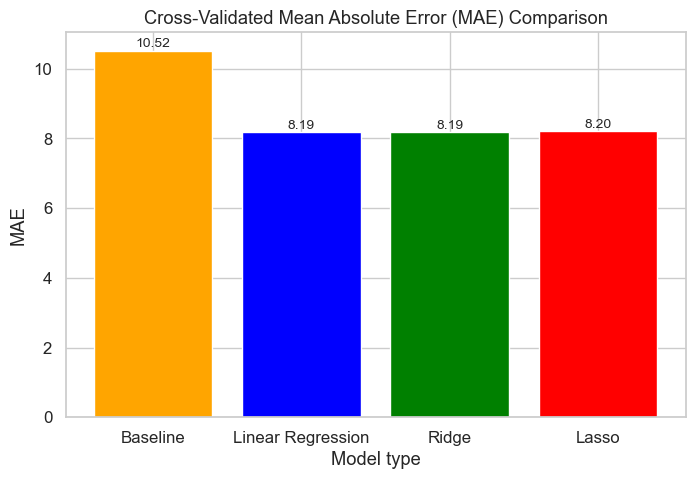

MAE Comparison:
Baseline: 10.52
Linear Regression: 8.19
Ridge: 8.19
Lasso: 8.20


In [37]:
# Compare your models
# Ask your AI: "Create a bar chart comparing CV MAE for baseline, linear regression, Ridge, and Lasso, with the values labelled on each bar."

import matplotlib.pyplot as plt

# Collect MAE values
models = ['Baseline', 'Linear Regression', 'Ridge', 'Lasso']
mae_values = [
    baseline_mae,
    cv_results['Linear Regression']['MAE'],
    cv_results['Ridge']['MAE'],
    cv_results['Lasso']['MAE']
]

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(models, mae_values, color=['orange', 'blue', 'green', 'red'])
plt.title('Cross-Validated Mean Absolute Error (MAE) Comparison')
plt.ylabel('MAE')
plt.xlabel('Model type')

# Add value labels on bars
for bar, value in zip(bars, mae_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{value:.2f}', 
             ha='center', va='bottom', fontsize=10)

plt.show()

# Also print the values
print("MAE Comparison:")
for model, mae in zip(models, mae_values):
    print(f"{model}: {mae:.2f}")

## Step 10: Interpret Coefficients

One of the strengths of linear models is **interpretability** — the coefficients tell you how much each feature contributes to the prediction.

A **negative coefficient** means higher values of that feature predict *lower* depression. A **positive coefficient** means higher values predict *higher* depression.

Create a horizontal bar chart of the coefficients from your best model. Which personality traits have the largest effect? Does this match what you'd expect from psychology?

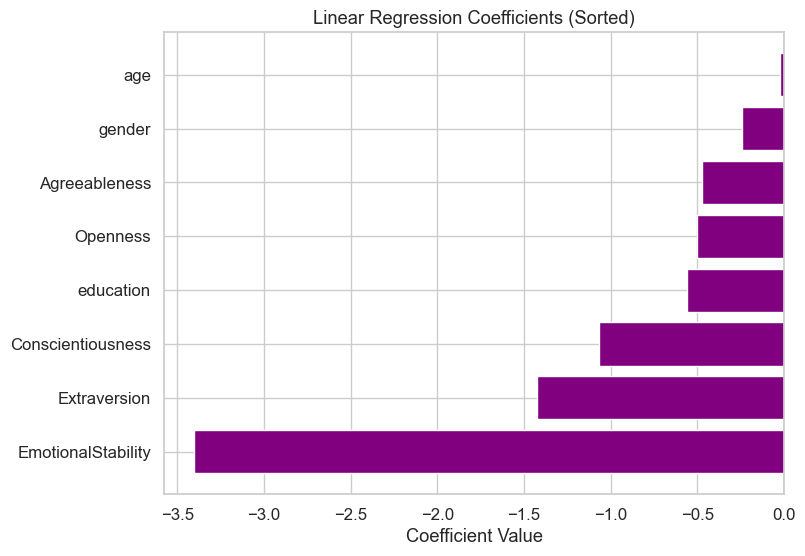

Coefficients:
EmotionalStability: -3.4044
Extraversion: -1.4263
Conscientiousness: -1.0690
education: -0.5623
Openness: -0.5019
Agreeableness: -0.4761
gender: -0.2409
age: -0.0220


In [44]:
# Plot regression coefficients
# Ask your AI: "Plot the regression coefficients from my linear model as a horizontal bar chart, sorted by value, with negative coefficients in red and positive in blue."

import matplotlib.pyplot as plt

# Fit linear model on training data
lr = LinearRegression()
lr.fit(X_train, y_train)

# Get coefficients and feature names
coeffs = lr.coef_
features_list = X_train.columns

# Create DataFrame for sorting
import pandas as pd
coeff_df = pd.DataFrame({'feature': features_list, 'coeff': coeffs})
coeff_df = coeff_df.sort_values('coeff')

# Plot horizontal bar chart
plt.figure(figsize=(8, 6))
colors = ['purple' if c < 0 else 'blue' for c in coeff_df['coeff']]
plt.barh(coeff_df['feature'], coeff_df['coeff'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients (Sorted)')
plt.axvline(0, color='black', linewidth=0.8)  # Add vertical line at 0
plt.show()

# Print coefficients for reference
print("Coefficients:")
for _, row in coeff_df.iterrows():
    print(f"{row['feature']}: {row['coeff']:.4f}")

## Step 11: Final Test Set Evaluation

**Now — and only now — unlock the test set.** Evaluate your best model on the held-out test data.

Compare the test performance to your cross-validated performance:
- If they're close → your model generalises well (no overfitting)
- If there's a big gap → your model may have overfit to the training data

Remember from Week 3: the test set is like a sealed exam. You only open it once, at the very end.

In [ ]:
# Evaluate your best model on the test set
# y_pred = best_model.predict(X_test)
# test_mae = mean_absolute_error(y_test, y_pred)
# test_r2 = r2_score(y_test, y_pred)
# print(f"Test MAE: {test_mae:.2f}")
# print(f"Test R²: {test_r2:.4f}")
# print(f"CV R² was: {cv_r2:.4f}")
# print(f"Gap: {abs(cv_r2 - test_r2):.4f}")


## Step 12: Document Your Findings

Take a moment to reflect on what you've done and learned. Edit this cell (double-click) with your answers:

**Which model performed best, and what was its CV R²?**

*Your answer here...*

**Which personality traits were the strongest predictors of depression?**

*Your answer here...*

**Does this match what you'd expect from psychological theory?**

*Your answer here...*

**Was there any overfitting (gap between CV and test performance)?**

*Your answer here...*

**What debugging challenges did you encounter? How did you solve them?**

*Your answer here...*

## Bonus Challenges

Finished early? Try one of these — see the [challenge brief](README.md#bonus-challenges) for full descriptions:

1. **Learning curves** — is your model underfitting or overfitting?
2. **Residual analysis** — are there patterns the model misses?
3. **Feature engineering** — interaction terms, polynomial features
4. **Compare DASS subscales** — do the same features predict Anxiety and Stress?
5. **Lasso regularisation path** — which features survive strong regularisation?
6. **Response time trap** — what happens if you include Q1E, Q2E, etc.?
7. **Data quality filtering** — does removing careless responders improve the model?
8. **Boston College COVID dataset** — try a completely different dataset
9. **Synthetic vs real** — compare with the Week 2 dataset